In [ ]:
# This is part of the manuscript titled "Feedback-mediated circulation and persistence of stochastic fluctuations in gene regulatory circuits"

# Correspondence with the paper

# Please note ;
# 1. The four TNF motifs : Double positive(++), Double negative(--), Negative positive(-+) and Positive negative(+-) motifs
# 2. alpha_x and alpha_y are production rates of X and Y
# 3. beta_x and beta_y are degradation rates of X and Y
# 4. Atau is the time-scale asymmetry given by beta_x/beta_y (here Atau is a list of time-scale asymmetry values)
# 5. Txy and Tyx are time averaging factors
# 6. xav = < x >, yav = < y > obtained from the stochastic simulation using Gillespie algorithm
# 7. stochastic simulation results averaged over n=100000 trajectories, tend is the end time of each simulated trajectory
# 8. G = H (feedback gain)
# 9. a1,a2,a3,a4 are the propensities and a0 is the total propensity
# 10. fxyp and fyxp are the derivatives of the production terms or the Hill functions 
# 11. The noise decomposition terms - intrinsic noise(x_intnoise, y_intnoise), extrinsic noise(x_extnoise, y_extnoise) and cyclic noise(x_cycnoise, y_cycnoise)
# 12. The data is exported and plotted 

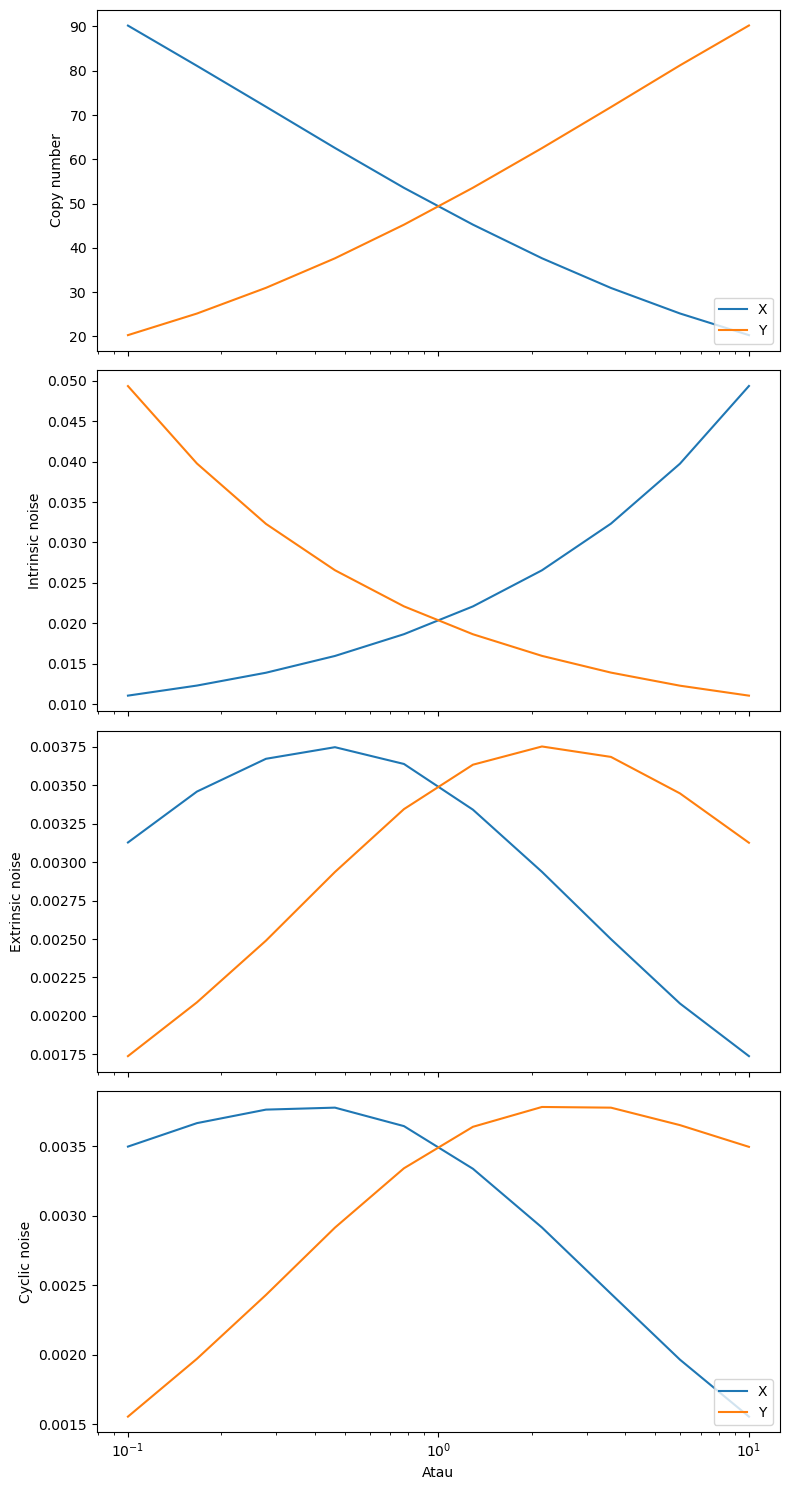

In [2]:
#double positive/ both activation

from numba import njit
import numpy as np
import matplotlib.pyplot as plt
import random

tend= 2000 #end time of the simulation
alpha_x=10
alpha_y=10
#beta_x=0.1
#beta_y=0.1
Atau=[0.1,0.1668,0.2783,0.4642,0.7743,1.2915,2.1544,3.5938,5.9948,10.0]
kxy=50
kyx=50
#Txy = beta_x/(beta_x + beta_y) #scaled time scale
#Tyx= beta_y/(beta_x + beta_y)
n=100000 #no.of realisations

f,(ax1,ax2,ax3,ax4) =plt.subplots(4, sharex = True, sharey = False, figsize=(8,15))

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0
    while t < tend:
        a1 = (alpha_x * y) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * x) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        #random numbers r1,r2
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1)   #update time
        
        if r2 * a0 < a1:
            x += 1
        elif r2 * a0 < a1 + a2:
            x -= 1
        elif r2 * a0 < a1 + a2 + a3:
            y += 1
        elif r2 * a0 < a1 + a2 + a3 + a4:
            y -= 1
    return x, y

xav_array=[]
yav_array=[]
xint=[]
yint=[]
xext=[]
yext=[]
xcyc=[]
ycyc=[]

for at in Atau:
    beta_x=(0.1)*np.sqrt(at)
    beta_y=(0.1)/(np.sqrt(at))
    Txy = beta_x/(beta_x + beta_y) #scaled time scale
    Tyx = beta_y/(beta_x + beta_y)
    
    x_last=[]      #to append last value(steady state) of each realisation
    y_last=[]
    
    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)
        
    xav = np.mean(x_last)
    yav = np.mean(y_last)
    xav_array.append(xav)
    yav_array.append(yav)
    
    #Derivatives
    fxyp= (alpha_x*kyx)/((yav+kyx)**2)
    fyxp= (alpha_y*kxy)/((xav+kxy)**2)
    
    #feedback gain
    G=(fxyp*fyxp)/(beta_x*beta_y)
    
    #noise
    x_intnoise = 1/xav
    y_intnoise = 1/yav
    xint.append(x_intnoise)
    yint.append(y_intnoise)
    
    x_extnoise= ((fxyp**2)*yav)/(beta_x*(beta_x+beta_y)*(xav**2)*(1-G))
    y_extnoise= ((fyxp**2)*xav)/(beta_y*(beta_x+beta_y)*(yav**2)*(1-G))
    xext.append(x_extnoise)
    yext.append(y_extnoise)
    
    x_cycnoise= (Tyx*G*x_intnoise)/(1-G)
    y_cycnoise= (Txy*G*y_intnoise)/(1-G)
    xcyc.append(x_cycnoise)
    ycyc.append(y_cycnoise)
    
plt.xscale('log')
ax1.plot(Atau,xav_array, label="X")
ax1.plot(Atau,yav_array, label="Y")

ax2.plot(Atau,xint, label="X")
ax2.plot(Atau,yint, label="Y")

ax3.plot(Atau,xext, label="X")
ax3.plot(Atau,yext, label="Y")

ax4.plot(Atau,xcyc, label="X")
ax4.plot(Atau,ycyc, label="Y")

ax1.set_ylabel("Copy number")
ax2.set_ylabel("Intrinsic noise")
ax3.set_ylabel("Extrinsic noise")
ax4.set_ylabel("Cyclic noise")
plt.xlabel("Atau")
ax1.legend(loc="lower right")
ax4.legend(loc="lower right")

np.savetxt('DPa_copynumber.dat',np.column_stack((Atau,xav_array,yav_array)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('DPa_intnoise.dat',np.column_stack((Atau,xint,yint)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('DPa_extnoise.dat',np.column_stack((Atau,xext,yext)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('DPa_cycnoise.dat',np.column_stack((Atau,xcyc,ycyc)), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()

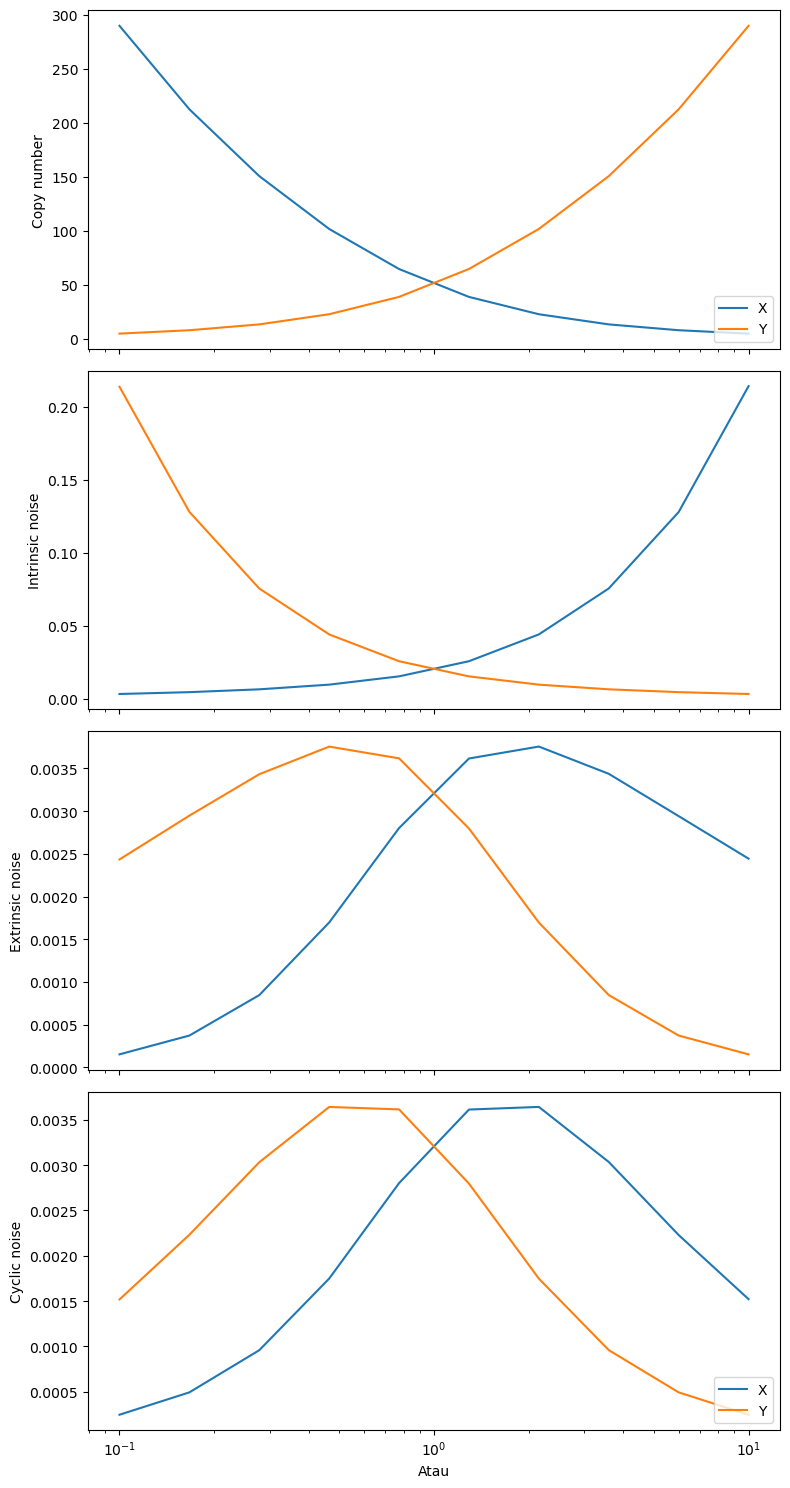

In [3]:
#double negative/ both repression

from numba import njit
import numpy as np
import matplotlib.pyplot as plt
import random

tend= 2000 #end time of the simulation
alpha_x=10
alpha_y=10
#beta_x=0.1
#beta_y=0.1
Atau=[0.1,0.1668,0.2783,0.4642,0.7743,1.2915,2.1544,3.5938,5.9948,10.0]
kxy=50
kyx=50
#Txy = beta_x/(beta_x + beta_y) #scaled time scale
#Tyx= beta_y/(beta_x + beta_y)
n=100000 #no.of realisations

f,(ax1,ax2,ax3,ax4) =plt.subplots(4, sharex = True, sharey = False, figsize=(8,15))

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0
    while t < tend:
        a1 = (alpha_x * kyx) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * kxy) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        #random numbers r1,r2
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1)   #update time
        
        if r2 * a0 < a1:
            x += 1
        elif r2 * a0 < a1 + a2:
            x -= 1
        elif r2 * a0 < a1 + a2 + a3:
            y += 1
        elif r2 * a0 < a1 + a2 + a3 + a4:
            y -= 1
    return x, y

xav_array=[]
yav_array=[]
xint=[]
yint=[]
xext=[]
yext=[]
xcyc=[]
ycyc=[]

for at in Atau:
    beta_x=(0.1)*np.sqrt(at)
    beta_y=(0.1)/(np.sqrt(at))
    Txy = beta_x/(beta_x + beta_y) #scaled time scale
    Tyx = beta_y/(beta_x + beta_y)
    
    x_last=[]      #to append last value(steady state) of each realisation
    y_last=[]
    
    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)
        
    xav = np.mean(x_last)
    yav = np.mean(y_last)
    xav_array.append(xav)
    yav_array.append(yav)
    
    #Derivatives
    fxyp= (-alpha_x*kyx)/((yav+kyx)**2)
    fyxp= (-alpha_y*kxy)/((xav+kxy)**2)
    
    #feedback gain
    G=(fxyp*fyxp)/(beta_x*beta_y)
    
    #noise
    x_intnoise = 1/xav
    y_intnoise = 1/yav
    xint.append(x_intnoise)
    yint.append(y_intnoise)
    
    x_extnoise= ((fxyp**2)*yav)/(beta_x*(beta_x+beta_y)*(xav**2)*(1-G))
    y_extnoise= ((fyxp**2)*xav)/(beta_y*(beta_x+beta_y)*(yav**2)*(1-G))
    xext.append(x_extnoise)
    yext.append(y_extnoise)
    
    x_cycnoise= (Tyx*G*x_intnoise)/(1-G)
    y_cycnoise= (Txy*G*y_intnoise)/(1-G)
    xcyc.append(x_cycnoise)
    ycyc.append(y_cycnoise)
    
plt.xscale('log')
ax1.plot(Atau,xav_array, label="X")
ax1.plot(Atau,yav_array, label="Y")

ax2.plot(Atau,xint, label="X")
ax2.plot(Atau,yint, label="Y")

ax3.plot(Atau,xext, label="X")
ax3.plot(Atau,yext, label="Y")

ax4.plot(Atau,xcyc, label="X")
ax4.plot(Atau,ycyc, label="Y")

ax1.set_ylabel("Copy number")
ax2.set_ylabel("Intrinsic noise")
ax3.set_ylabel("Extrinsic noise")
ax4.set_ylabel("Cyclic noise")
plt.xlabel("Atau")
ax1.legend(loc="lower right")
ax4.legend(loc="lower right")

np.savetxt('DNa_copynumber.dat',np.column_stack((Atau,xav_array,yav_array)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('DNa_intnoise.dat',np.column_stack((Atau,xint,yint)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('DNa_extnoise.dat',np.column_stack((Atau,xext,yext)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('DNa_cycnoise.dat',np.column_stack((Atau,xcyc,ycyc)), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()

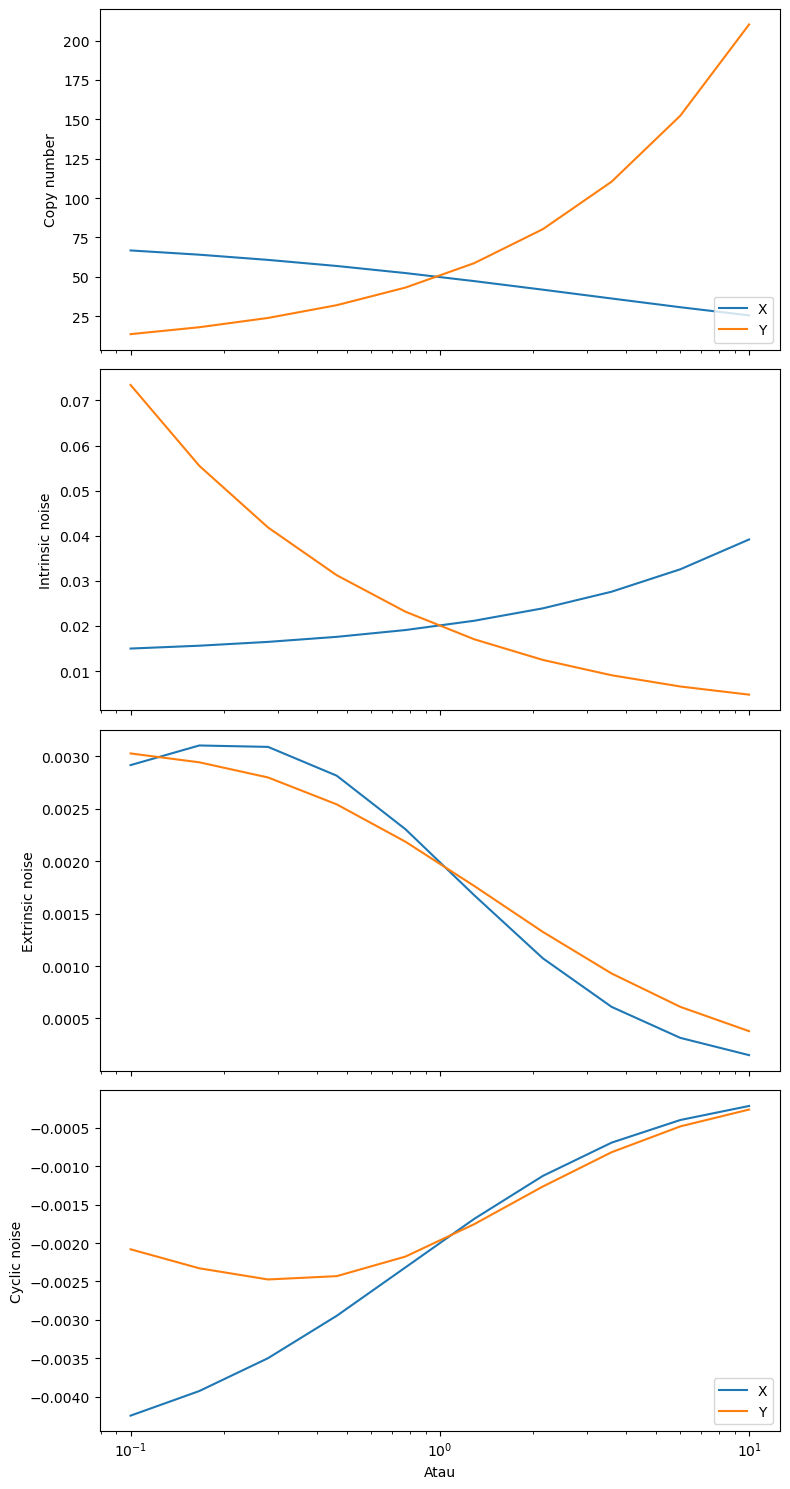

In [4]:
#negative positive/ x represses y, y activates x

from numba import njit
import numpy as np
import matplotlib.pyplot as plt
import random

tend= 2000 #end time of the simulation
alpha_x=10
alpha_y=10
#beta_x=0.1
#beta_y=0.1
Atau=[0.1,0.1668,0.2783,0.4642,0.7743,1.2915,2.1544,3.5938,5.9948,10.0]
kxy=50
kyx=50
#Txy = beta_x/(beta_x + beta_y) #scaled time scale
#Tyx= beta_y/(beta_x + beta_y)
n=100000 #no.of realisations

f,(ax1,ax2,ax3,ax4) =plt.subplots(4, sharex = True, sharey = False, figsize=(8,15))

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0
    while t < tend:
        a1 = (alpha_x * y) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * kxy) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        #random numbers r1,r2
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1)   #update time
        
        if r2 * a0 < a1:
            x += 1
        elif r2 * a0 < a1 + a2:
            x -= 1
        elif r2 * a0 < a1 + a2 + a3:
            y += 1
        elif r2 * a0 < a1 + a2 + a3 + a4:
            y -= 1
    return x, y

xav_array=[]
yav_array=[]
xint=[]
yint=[]
xext=[]
yext=[]
xcyc=[]
ycyc=[]

for at in Atau:
    beta_x=(0.1)*np.sqrt(at)
    beta_y=(0.1)/(np.sqrt(at))
    Txy = beta_x/(beta_x + beta_y) #scaled time scale
    Tyx = beta_y/(beta_x + beta_y)
    
    x_last=[]      #to append last value(steady state) of each realisation
    y_last=[]
    
    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)
        
    xav = np.mean(x_last)
    yav = np.mean(y_last)
    xav_array.append(xav)
    yav_array.append(yav)
    
    #Derivatives
    fxyp= (alpha_x*kyx)/((yav+kyx)**2)
    fyxp= (-alpha_y*kxy)/((xav+kxy)**2)
    
    #feedback gain
    G=(fxyp*fyxp)/(beta_x*beta_y)
    
    #noise
    x_intnoise = 1/xav
    y_intnoise = 1/yav
    xint.append(x_intnoise)
    yint.append(y_intnoise)
    
    x_extnoise= ((fxyp**2)*yav)/(beta_x*(beta_x+beta_y)*(xav**2)*(1-G))
    y_extnoise= ((fyxp**2)*xav)/(beta_y*(beta_x+beta_y)*(yav**2)*(1-G))
    xext.append(x_extnoise)
    yext.append(y_extnoise)
    
    x_cycnoise= (Tyx*G*x_intnoise)/(1-G)
    y_cycnoise= (Txy*G*y_intnoise)/(1-G)
    xcyc.append(x_cycnoise)
    ycyc.append(y_cycnoise)
    
plt.xscale('log')
ax1.plot(Atau,xav_array, label="X")
ax1.plot(Atau,yav_array, label="Y")

ax2.plot(Atau,xint, label="X")
ax2.plot(Atau,yint, label="Y")

ax3.plot(Atau,xext, label="X")
ax3.plot(Atau,yext, label="Y")

ax4.plot(Atau,xcyc, label="X")
ax4.plot(Atau,ycyc, label="Y")

ax1.set_ylabel("Copy number")
ax2.set_ylabel("Intrinsic noise")
ax3.set_ylabel("Extrinsic noise")
ax4.set_ylabel("Cyclic noise")
plt.xlabel("Atau")
ax1.legend(loc="lower right")
ax4.legend(loc="lower right")

np.savetxt('NPa_copynumber.dat',np.column_stack((Atau,xav_array,yav_array)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('NPa_intnoise.dat',np.column_stack((Atau,xint,yint)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('NPa_extnoise.dat',np.column_stack((Atau,xext,yext)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('NPa_cycnoise.dat',np.column_stack((Atau,xcyc,ycyc)), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()

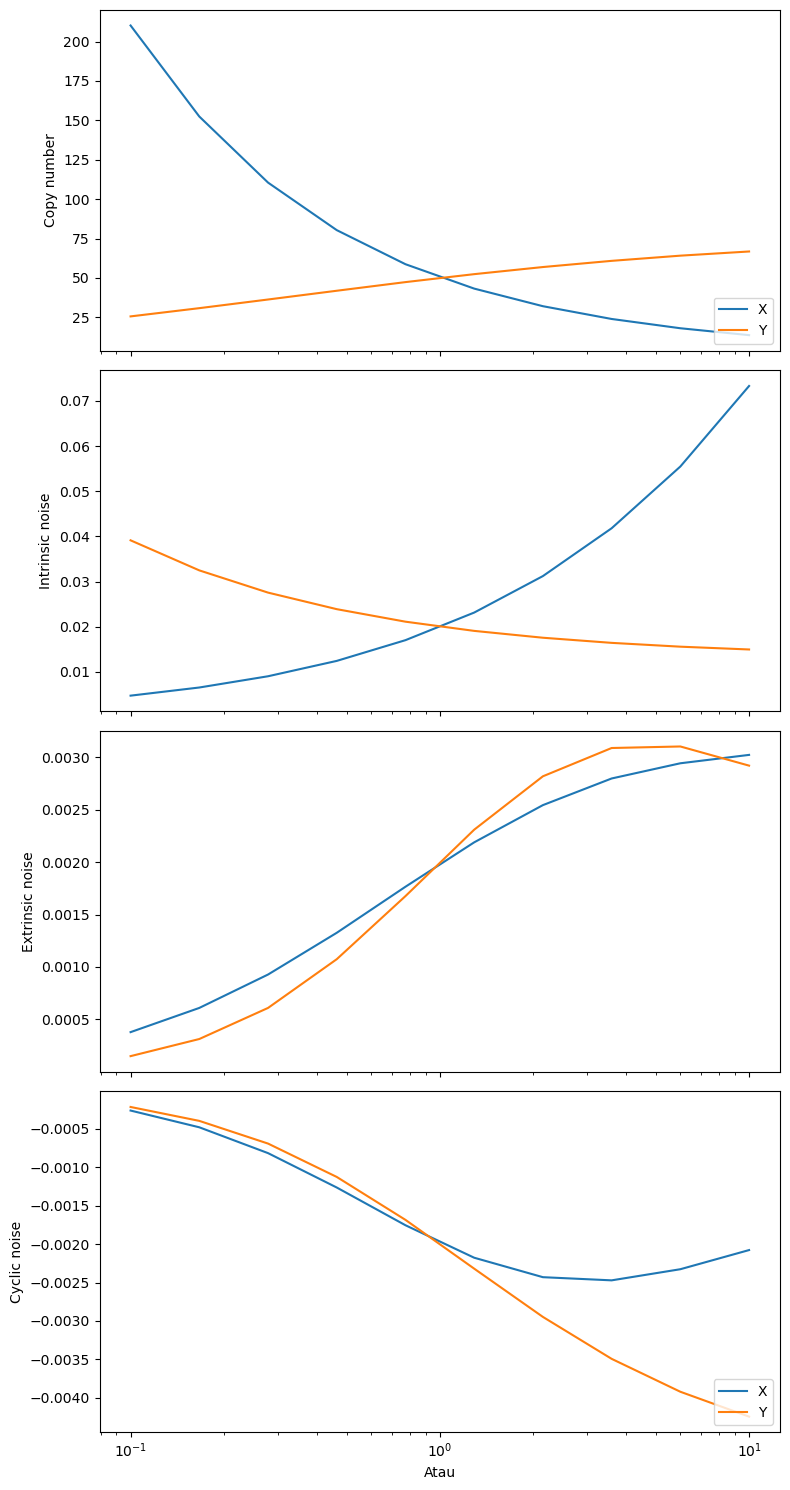

In [5]:
#positive negative/ x activates y, y represses x

from numba import njit
import numpy as np
import matplotlib.pyplot as plt
import random

tend= 2000 #end time of the simulation
alpha_x=10
alpha_y=10
#beta_x=0.1
#beta_y=0.1
Atau=[0.1,0.1668,0.2783,0.4642,0.7743,1.2915,2.1544,3.5938,5.9948,10.0]
kxy=50
kyx=50
#Txy = beta_x/(beta_x + beta_y) #scaled time scale
#Tyx= beta_y/(beta_x + beta_y)
n=100000 #no.of realisations

f,(ax1,ax2,ax3,ax4) =plt.subplots(4, sharex = True, sharey = False, figsize=(8,15))

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0
    while t < tend:
        a1 = (alpha_x * kyx) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * x) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        #random numbers r1,r2
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1)   #update time
        
        if r2 * a0 < a1:
            x += 1
        elif r2 * a0 < a1 + a2:
            x -= 1
        elif r2 * a0 < a1 + a2 + a3:
            y += 1
        elif r2 * a0 < a1 + a2 + a3 + a4:
            y -= 1
    return x, y

xav_array=[]
yav_array=[]
xint=[]
yint=[]
xext=[]
yext=[]
xcyc=[]
ycyc=[]

for at in Atau:
    beta_x=(0.1)*np.sqrt(at)
    beta_y=(0.1)/(np.sqrt(at))
    Txy = beta_x/(beta_x + beta_y) #scaled time scale
    Tyx = beta_y/(beta_x + beta_y)
    
    x_last=[]      #to append last value(steady state) of each realisation
    y_last=[]
    
    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)
        
    xav = np.mean(x_last)
    yav = np.mean(y_last)
    xav_array.append(xav)
    yav_array.append(yav)
    
    #Derivatives
    fxyp= (-alpha_x*kyx)/((yav+kyx)**2)
    fyxp= (alpha_y*kxy)/((xav+kxy)**2)
    
    #feedback gain
    G=(fxyp*fyxp)/(beta_x*beta_y)
    
    #noise
    x_intnoise = 1/xav
    y_intnoise = 1/yav
    xint.append(x_intnoise)
    yint.append(y_intnoise)
    
    x_extnoise= ((fxyp**2)*yav)/(beta_x*(beta_x+beta_y)*(xav**2)*(1-G))
    y_extnoise= ((fyxp**2)*xav)/(beta_y*(beta_x+beta_y)*(yav**2)*(1-G))
    xext.append(x_extnoise)
    yext.append(y_extnoise)
    
    x_cycnoise= (Tyx*G*x_intnoise)/(1-G)
    y_cycnoise= (Txy*G*y_intnoise)/(1-G)
    xcyc.append(x_cycnoise)
    ycyc.append(y_cycnoise)
    
plt.xscale('log')
ax1.plot(Atau,xav_array, label="X")
ax1.plot(Atau,yav_array, label="Y")

ax2.plot(Atau,xint, label="X")
ax2.plot(Atau,yint, label="Y")

ax3.plot(Atau,xext, label="X")
ax3.plot(Atau,yext, label="Y")

ax4.plot(Atau,xcyc, label="X")
ax4.plot(Atau,ycyc, label="Y")

ax1.set_ylabel("Copy number")
ax2.set_ylabel("Intrinsic noise")
ax3.set_ylabel("Extrinsic noise")
ax4.set_ylabel("Cyclic noise")
plt.xlabel("Atau")
ax1.legend(loc="lower right")
ax4.legend(loc="lower right")

np.savetxt('PNa_copynumber.dat',np.column_stack((Atau,xav_array,yav_array)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('PNa_intnoise.dat',np.column_stack((Atau,xint,yint)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('PNa_extnoise.dat',np.column_stack((Atau,xext,yext)), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('PNa_cycnoise.dat',np.column_stack((Atau,xcyc,ycyc)), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()